In [1]:
import numpy as np

from mbloodmoon.io import simulation_files, simulation
from mbloodmoon.mask import codedmask

from _IROS_support import _handle_dirpaths
from singleCAM_iros import run_IROS

In [2]:
mask_FITS = "wfm_mask.fits"
skyfield = "IROSDummy"
data_FITS = "catalog_noCXB_1Crab_infdet_2-50keV_1ks"

N_TEST = "testing"

mask_path, simul_data, save_path = _handle_dirpaths(
    mask=mask_FITS,
    skyfield=skyfield,
    simul=data_FITS,
    test_name=N_TEST,
)

VIGNETTING = True
PSFY = False
UPX, UPY = 5, 1
wfm = codedmask(mask_path, UPX, UPY)

cam_a = 'cam1a'
dataset = 'detected'
filepaths = simulation_files(simul_data)

sdlA = simulation(filepaths[cam_a][dataset], energy_range=None, coords=None)
catalogueA = simulation(filepaths[cam_a]["sources"])

In [3]:
MAX_ITERATIONS = 9
SNR_THRESHOLD = 10
SKY_START = None

db, residual = run_IROS(
    camera=wfm,
    sdl=sdlA,
    max_iterations=MAX_ITERATIONS,
    snr_threshold=SNR_THRESHOLD,
    vignetting=VIGNETTING,
    psfy=PSFY,
    sky_start=SKY_START,
)

# Looping around the FOV...


0it [00:00, ?it/s]


FLUENCE START: 112576.17931273804
SHIFTS START: (-1.4110854715202004e-14, -2.5645352591003756e-15)

FINAL OPTIMIZED FLUENCE: 113866.62571930945
FLUENCE GAIN: 1.146%
FINAL OPTIMIZED SHIFTS: (-1.476065711934183e-14, -2.5829451534468378e-15)
SHIFTX GAIN: 4.605%
SHIFTY GAIN: 0.718%



1it [00:30, 30.60s/it]


FLUENCE START: 100820.59115754876
SHIFTS START: (-1.4110854715202004e-14, 41.377777777777766)

FINAL OPTIMIZED FLUENCE: 103677.21353521418
FLUENCE GAIN: 2.833%
FINAL OPTIMIZED SHIFTS: (-1.450419441540974e-14, 41.219046548704924)
SHIFTX GAIN: 2.787%
SHIFTY GAIN: -0.384%



...

7it [04:42, 41.43s/it]


FLUENCE START: 23364.797425105546
SHIFTS START: (-1.4110854715202004e-14, 165.3777777777778)

FINAL OPTIMIZED FLUENCE: 23405.89273932219
FLUENCE GAIN: 0.176%
FINAL OPTIMIZED SHIFTS: (-1.4160118207906219e-14, 165.42597271780465)
SHIFTX GAIN: 0.349%
SHIFTY GAIN: 0.029%



8it [05:36, 45.56s/it]


FLUENCE START: 16034.947861180683
SHIFTS START: (166.7111111111111, -2.5645352591003756e-15)

FINAL OPTIMIZED FLUENCE: 15933.939705810357
FLUENCE GAIN: -0.630%
FINAL OPTIMIZED SHIFTS: (166.7893249240041, -2.6637888996585093e-15)
SHIFTX GAIN: 0.047%
SHIFTY GAIN: 3.870%



9it [06:16, 41.87s/it]


In [4]:
from mbloodmoon.coords import shift2equatorial
from mbloodmoon.io import SimulationDataLoader
from mbloodmoon.mask import CodedMaskCamera

def catalog_comparison(
    data: dict,
    catalogue: np.recarray,
    camera: CodedMaskCamera,
    sdl: SimulationDataLoader,
) -> dict:
    """
    """
    def optimized_pos(
        pos: tuple[float, float],
    ) -> int:
        """Source association from catalog."""
        arg = np.argmin(np.square(catalogue["RA"] - pos[0]) + np.square(catalogue["DEC"] - pos[1]))
        return arg
    
    data['id'] = []
    for sx, sy in zip(data["shift_x"], data["shift_y"]):
        ra, dec = shift2equatorial(sdl, camera, sx, sy)
        argsource = optimized_pos((ra, dec))
        data['id'].append(catalogue["NAME"][argsource])
    
    return data

db = catalog_comparison(db, catalogueA.data, wfm, sdlA)

In [5]:
from mbloodmoon.coords import shift2angle, equatorial2shift

def get_catalog_theta(
    data: dict,
    catalogue: np.recarray,
    sdl: SimulationDataLoader,
    camera: CodedMaskCamera,
) -> dict:
    """Returns catalog sources respective camera angular coordinates."""
    db = {
        "id": [],
        "theta_x": [],
        "theta_y": [],
    }

    for name in data["id"]:
        cat_ra = catalogue[catalogue["NAME"] == name]["RA"][0]
        cat_dec = catalogue[catalogue["NAME"] == name]["DEC"][0]
        sx, sy = equatorial2shift(sdl, camera, cat_ra, cat_dec)
        db["id"].append(name)
        db["theta_x"].append(shift2angle(camera, sx))
        db["theta_y"].append(shift2angle(camera, sy))

    return db


thetax = shift2angle(wfm, np.array(db['shift_x'])) # [deg]
thetay = shift2angle(wfm, np.array(db['shift_y'])) # [deg]

cat_theta = get_catalog_theta(db, catalogueA.data, sdlA, wfm)
cat_thetax = cat_theta['theta_x']
cat_thetay = cat_theta['theta_y']

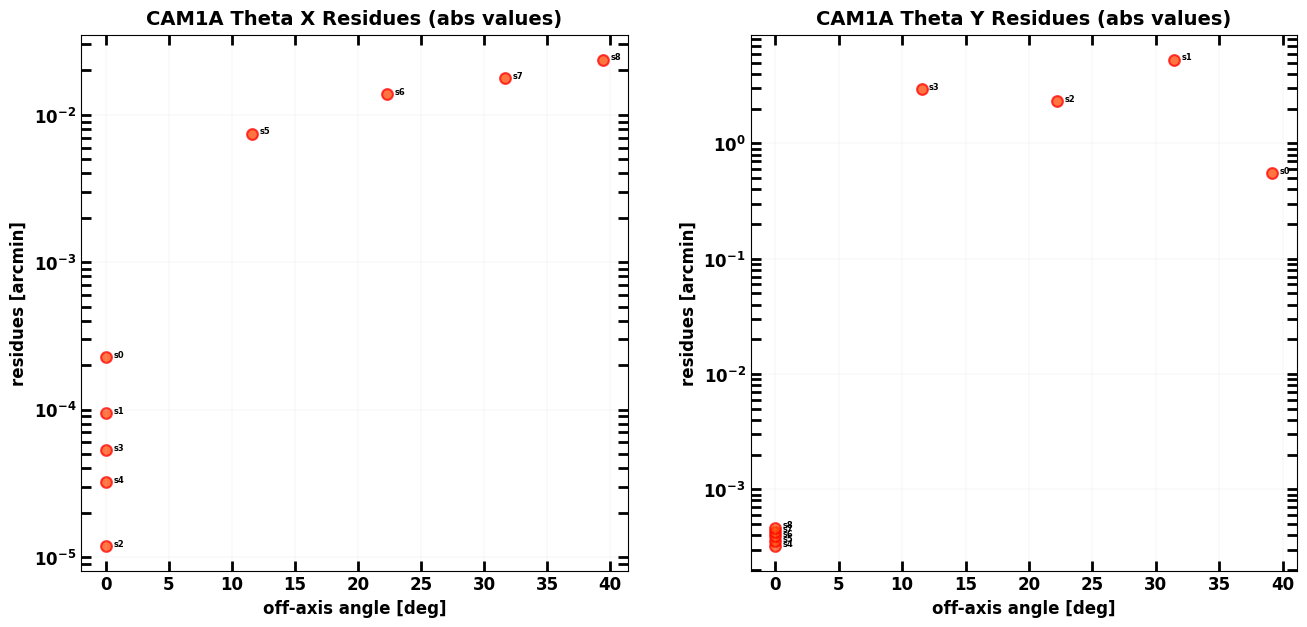

In [6]:
import matplotlib.pyplot as plt
import matplotlib as mpl

def _handle_subplots(nplots, spacing=0.27):
    """Creates and configures subplots."""
    size = 6
    fig_size = (size * nplots + 1, size) if nplots > 1 else (size, size)
    fig, axes = plt.subplots(1, nplots, figsize=fig_size)
    fig.tight_layout()
    fig.subplots_adjust(wspace=spacing * 5 / size)
    return fig, (axes if nplots > 1 else [axes])

def _set_labels(ax, xlabel, ylabel, title):
    """Configures labels and titles."""
    ax.set_xlabel(xlabel or "", fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel or "", fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, pad=8, fontweight='bold')

def _set_ticks(ax):
    """Configures grid and tick properties."""
    ax.grid(visible=True, color="lightgray", linestyle="-", linewidth=0.2, alpha=0.70)
    ax.tick_params(which='both', direction='in', width=2, length=7 if 'major' else 4)
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    ax.ticklabel_format(scilimits=(-3, 4))

RCPARAMS = {
    'font.family': 'sans-serif',
    'font.weight': 'bold',
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
}
PCAM = {
    "sourcename_fs": 6,
    "title_fs": 12,
    "title_pad": 8,
    "txt_fw": "bold",
    "txt_color": "black",
}
mpl.rcParams.update(RCPARAMS)


fig, axes = _handle_subplots(2)
for (i, ax), xval, yval, title in zip(
    enumerate(axes),
    (cat_thetax, cat_thetay),
    (60 * np.abs(thetax - cat_thetax), 60 * np.abs(thetay - cat_thetay)),
    (f'{cam_a.upper()} Theta X Residues (abs values)', f'{cam_a.upper()} Theta Y Residues (abs values)')
):
    fcolor, ecolor = ('OrangeRed', 'r')
    _set_labels(ax, 'off-axis angle [deg]', 'residues [arcmin]', title)
    _set_ticks(ax)
    ax.set_yscale('log')
    ax.scatter(xval, yval, c=fcolor, edgecolors=ecolor, s=60, alpha=0.75, linewidths=1.5)
    for idx, name in enumerate(db['id']):
        ax.text(
            xval[idx] + 0.6, yval[idx], name, color=PCAM["txt_color"],
            fontsize=PCAM["sourcename_fs"], fontweight=PCAM["txt_fw"],
        )
plt.show()